# Laboratory Assignment 8: High-Performance Big Data Analytics Using R
## NYC Yellow Taxi Trip Records


## 1. Install and load the required R packages

In [22]:
required_packages <- c("arrow", "data.table", "lubridate", "ggplot2",
                       "foreach", "doParallel", "microbenchmark", "purrr")
missing_packages <- required_packages[
  !vapply(required_packages, requireNamespace, logical(1), quietly = TRUE)
]
if (length(missing_packages) > 0) {
  install.packages(missing_packages, repos = "https://cloud.r-project.org")
}
invisible(lapply(required_packages, library, character.only = TRUE))
cat("All required packages are loaded.\n")

All required packages are loaded.


## 2. Locate the uploaded files

In [23]:
trip_file <- "/content/yellow_tripdata_2026-01.parquet"
zone_file <- "/content/taxi_zone_lookup.csv"

if (!file.exists(trip_file)) {
  stop("Trip file not found. Upload yellow_tripdata_2026-01.parquet using the Colab Files panel.")
}
if (!file.exists(zone_file)) {
  stop("Zone lookup CSV not found. Upload taxi_zone_lookup.csv using the Colab Files panel.")
}
cat("Trip file:", trip_file, "\n")
cat("Zone file:", zone_file, "\n")

Trip file: /content/yellow_tripdata_2026-01.parquet 
Zone file: /content/taxi_zone_lookup.csv 


In [24]:
trip_file <- "/content/yellow_tripdata_2026-01.parquet"

file.info(trip_file)$size

con <- file(trip_file, "rb")
first_bytes <- readBin(con, "raw", n = 4)

file_size <- file.info(trip_file)$size
seek(con, where = file_size - 4, origin = "start")
last_bytes <- readBin(con, "raw", n = 4)
close(con)

cat("First bytes:", rawToChar(first_bytes), "\n")
cat("Last bytes:", rawToChar(last_bytes), "\n")

[1] 64165080

[1] 4

First bytes: PAR1 
Last bytes: PAR1 


## 3. Read the datasets and inspect their structure

In [25]:
trips <- data.table::as.data.table(arrow::read_parquet(trip_file))
zones <- data.table::fread(zone_file)

cat("Trip data:", nrow(trips), "rows x", ncol(trips), "columns\n")
cat("Zone lookup:", nrow(zones), "rows x", ncol(zones), "columns\n")
cat("\nTrip columns:\n")
print(names(trips))
cat("\nZone columns:\n")
print(names(zones))
str(trips)
summary(trips)
head(zones)

Trip data: 3724889 rows x 20 columns
Zone lookup: 265 rows x 4 columns

Trip columns:
 [1] "VendorID"              "tpep_pickup_datetime"  "tpep_dropoff_datetime"
 [4] "passenger_count"       "trip_distance"         "RatecodeID"           
 [7] "store_and_fwd_flag"    "PULocationID"          "DOLocationID"         
[10] "payment_type"          "fare_amount"           "extra"                
[13] "mta_tax"               "tip_amount"            "tolls_amount"         
[16] "improvement_surcharge" "total_amount"          "congestion_surcharge" 
[19] "Airport_fee"           "cbd_congestion_fee"   

Zone columns:
[1] "LocationID"   "Borough"      "Zone"         "service_zone"
Classes ‘data.table’ and 'data.frame':	3724889 obs. of  20 variables:
 $ VendorID             : int  2 1 1 2 2 2 1 1 2 2 ...
 $ tpep_pickup_datetime : POSIXct, format: "2026-01-01 00:54:04" "2026-01-01 00:34:04" ...
 $ tpep_dropoff_datetime: POSIXct, format: "2026-01-01 00:59:37" "2026-01-01 00:39:47" ...
 $ passenger_

    VendorID     tpep_pickup_datetime          tpep_dropoff_datetime        
 Min.   :1.000   Min.   :2025-12-31 23:57:29   Min.   :2025-12-31 23:57:32  
 1st Qu.:2.000   1st Qu.:2026-01-09 17:51:59   1st Qu.:2026-01-09 18:08:47  
 Median :2.000   Median :2026-01-16 21:20:56   Median :2026-01-16 21:36:14  
 Mean   :1.874   Mean   :2026-01-17 01:44:52   Mean   :2026-01-17 02:02:03  
 3rd Qu.:2.000   3rd Qu.:2026-01-24 07:25:11   3rd Qu.:2026-01-24 07:40:22  
 Max.   :7.000   Max.   :2026-02-01 00:45:01   Max.   :2026-02-01 23:35:31  
                                                                            
 passenger_count   trip_distance         RatecodeID      store_and_fwd_flag 
 Min.   :0.000     Min.   :0.000e+00   Min.   : 1.000    Length   :3724889  
 1st Qu.:1.000     1st Qu.:1.000e+00   1st Qu.: 1.000    N.unique :      2  
 Median :1.000     Median :1.810e+00   Median : 1.000    N.blank  :      0  
 Mean   :1.256     Mean   :6.456e+00   Mean   : 5.219    Min.nchar:      1  

LocationID,Borough,Zone,service_zone
<int>,<chr>,<chr>,<chr>
1,EWR,Newark Airport,EWR
2,Queens,Jamaica Bay,Boro Zone
3,Bronx,Allerton/Pelham Gardens,Boro Zone
4,Manhattan,Alphabet City,Yellow Zone
5,Staten Island,Arden Heights,Boro Zone
6,Staten Island,Arrochar/Fort Wadsworth,Boro Zone


## 4. Check missing values and duplicate records

In [26]:
missing_counts <- sort(colSums(is.na(trips)), decreasing = TRUE)
print(missing_counts[1:min(20, length(missing_counts))])
cat("Exact duplicate rows:", sum(duplicated(trips)), "\n")

      passenger_count            RatecodeID    store_and_fwd_flag 
              1088058               1088058               1088058 
 congestion_surcharge           Airport_fee              VendorID 
              1088058               1088058                     0 
 tpep_pickup_datetime tpep_dropoff_datetime         trip_distance 
                    0                     0                     0 
         PULocationID          DOLocationID          payment_type 
                    0                     0                     0 
          fare_amount                 extra               mta_tax 
                    0                     0                     0 
           tip_amount          tolls_amount improvement_surcharge 
                    0                     0                     0 
         total_amount    cbd_congestion_fee 
                    0                     0 
Exact duplicate rows: 0 


## 5. Clean records and derive time attributes

In [27]:
first_existing <- function(x, candidates) {
  hit <- candidates[candidates %in% x]
  if (length(hit)) hit[1] else NA_character_
}

pickup_col <- first_existing(names(trips), c("tpep_pickup_datetime", "pickup_datetime"))
dropoff_col <- first_existing(names(trips), c("tpep_dropoff_datetime", "dropoff_datetime"))
pickup_loc_col <- first_existing(names(trips), c("PULocationID", "pickup_location_id"))
dropoff_loc_col <- first_existing(names(trips), c("DOLocationID", "dropoff_location_id"))
distance_col <- first_existing(names(trips), c("trip_distance"))
fare_col <- first_existing(names(trips), c("fare_amount"))
total_col <- first_existing(names(trips), c("total_amount"))
payment_col <- first_existing(names(trips), c("payment_type"))

required_cols <- c(pickup_col, dropoff_col, pickup_loc_col, dropoff_loc_col,
                   distance_col, fare_col, total_col)
if (anyNA(required_cols)) {
  stop(paste("Required columns not found. Available columns:",
             paste(names(trips), collapse = ", ")))
}

trips <- unique(trips)
trips[, (pickup_col) := as.POSIXct(get(pickup_col), tz = "UTC")]
trips[, (dropoff_col) := as.POSIXct(get(dropoff_col), tz = "UTC")]

trips <- trips[
  !is.na(get(pickup_col)) &
  !is.na(get(dropoff_col)) &
  get(dropoff_col) >= get(pickup_col) &
  !is.na(get(distance_col)) & get(distance_col) >= 0 &
  !is.na(get(fare_col)) & get(fare_col) >= 0 &
  !is.na(get(total_col)) & get(total_col) >= 0
]

trips[, pickup_hour := lubridate::hour(get(pickup_col))]
trips[, pickup_day := lubridate::day(get(pickup_col))]
trips[, pickup_weekday := factor(
  lubridate::wday(get(pickup_col), label = TRUE, abbr = FALSE),
  levels = c("Sunday", "Monday", "Tuesday", "Wednesday",
             "Thursday", "Friday", "Saturday")
)]
trips[, pickup_month := lubridate::month(get(pickup_col), label = TRUE, abbr = FALSE)]
trips[, trip_duration_min := as.numeric(
  difftime(get(dropoff_col), get(pickup_col), units = "mins")
)]

cat("Rows after cleaning:", nrow(trips), "\n")
cat("Columns after feature engineering:", ncol(trips), "\n")
summary(trips[, .(
  trip_distance = get(distance_col),
  fare_amount = get(fare_col),
  total_amount = get(total_col),
  trip_duration_min
)])

Rows after cleaning: 3684886 
Columns after feature engineering: 25 


 trip_distance        fare_amount       total_amount     trip_duration_min
 Min.   :0.000e+00   Min.   :   0.00   Min.   :   0.00   Min.   :   0.00  
 1st Qu.:1.000e+00   1st Qu.:  10.00   1st Qu.:  17.22   1st Qu.:   8.10  
 Median :1.820e+00   Median :  15.60   Median :  23.18   Median :  13.38  
 Mean   :6.482e+00   Mean   :  21.29   Mean   :  29.82   Mean   :  17.21  
 3rd Qu.:3.720e+00   3rd Qu.:  26.18   3rd Qu.:  33.95   3rd Qu.:  21.20  
 Max.   :2.691e+05   Max.   :2555.20   Max.   :2560.20   Max.   :7507.90  

## 6. Join taxi zones to pickup and drop-off IDs

In [28]:
zone_id_col <- first_existing(names(zones), c("LocationID", "location_id"))
borough_col <- first_existing(names(zones), c("Borough", "borough"))
zone_name_col <- first_existing(names(zones), c("Zone", "zone"))

if (anyNA(c(zone_id_col, borough_col, zone_name_col))) {
  stop(paste("Lookup columns not found. Available columns:", paste(names(zones), collapse = ", ")))
}

zones_clean <- unique(zones[, .(
  location_join = as.integer(get(zone_id_col)),
  borough_join = as.character(get(borough_col)),
  zone_join = as.character(get(zone_name_col))
)])

trips[, (pickup_loc_col) := as.integer(get(pickup_loc_col))]
trips[, (dropoff_loc_col) := as.integer(get(dropoff_loc_col))]

pickup_zones <- copy(zones_clean)
setnames(pickup_zones, c("location_join", "borough_join", "zone_join"),
         c(pickup_loc_col, "pickup_borough", "pickup_zone"))
dropoff_zones <- copy(zones_clean)
setnames(dropoff_zones, c("location_join", "borough_join", "zone_join"),
         c(dropoff_loc_col, "dropoff_borough", "dropoff_zone"))

trips <- merge(trips, pickup_zones, by = pickup_loc_col, all.x = TRUE, sort = FALSE)
trips <- merge(trips, dropoff_zones, by = dropoff_loc_col, all.x = TRUE, sort = FALSE)

print(trips[1:min(6, .N),
  .(pickup_zone, pickup_borough, dropoff_zone, dropoff_borough)])

                pickup_zone pickup_borough          dropoff_zone
                     <char>         <char>                <char>
1:    Upper West Side South      Manhattan Upper West Side North
2:            Midtown North      Manhattan          Midtown East
3:             Central Park      Manhattan Upper East Side South
4:      Lincoln Square East      Manhattan               Seaport
5: Financial District South      Manhattan   Little Italy/NoLiTa
6:      Little Italy/NoLiTa      Manhattan              Kips Bay
   dropoff_borough
            <char>
1:       Manhattan
2:       Manhattan
3:       Manhattan
4:       Manhattan
5:       Manhattan
6:       Manhattan


## 7. Transportation analytics using data.table

In [29]:
# Payment type distribution
if (!is.na(payment_col)) {
  payment_summary <- trips[, .(
    trip_count = .N,
    total_revenue = sum(get(total_col), na.rm = TRUE)
  ), by = .(payment_type = get(payment_col))][order(-trip_count)]

  print(payment_summary)
} else {
  cat("Payment type column was not found in this dataset.\n")
}

   payment_type trip_count total_revenue
          <int>      <int>         <num>
1:            1    2249478    66619359.2
2:            0    1088026    34474035.6
3:            2     304873     7641016.9
4:            4      30361      886966.1
5:            3      12148      278865.3


## 8. Functional programming, vectorization, and data.table

In [30]:
# Use a sample for fair, practical benchmarking of alternative implementations.
set.seed(42)
sample_n <- min(100000L, nrow(trips))
sample_trips <- trips[sample.int(nrow(trips), sample_n)]

base_vectorized <- function(d) {
  tapply(d[[fare_col]], d$pickup_hour, mean, na.rm = TRUE)
}
functional_lapply <- function(d) {
  lapply(0:23, function(h) {
    mean(d[d$pickup_hour == h][[fare_col]], na.rm = TRUE)
  })
}
datatable_group <- function(d) {
  d[, .(mean_fare = mean(get(fare_col), na.rm = TRUE)), by = pickup_hour]
}

print(base_vectorized(sample_trips))
print(functional_lapply(sample_trips))
print(datatable_group(sample_trips))

functional_benchmark <- microbenchmark::microbenchmark(
  vectorized = base_vectorized(sample_trips),
  lapply = functional_lapply(sample_trips),
  data_table = datatable_group(sample_trips),
  times = 5L
)
print(functional_benchmark)

       0        1        2        3        4        5        6        7 
23.07968 21.77072 20.76293 20.44691 23.82975 26.56967 25.50528 24.46812 
       8        9       10       11       12       13       14       15 
22.48340 20.79186 19.86644 20.09792 20.17929 20.08919 21.28057 21.72431 
      16       17       18       19       20       21       22       23 
21.59947 21.11360 20.33067 20.81029 20.88873 21.06534 21.09861 22.77406 
[[1]]
[1] 23.07968

[[2]]
[1] 21.77072

[[3]]
[1] 20.76293

[[4]]
[1] 20.44691

[[5]]
[1] 23.82975

[[6]]
[1] 26.56967

[[7]]
[1] 25.50528

[[8]]
[1] 24.46812

[[9]]
[1] 22.4834

[[10]]
[1] 20.79186

[[11]]
[1] 19.86644

[[12]]
[1] 20.09792

[[13]]
[1] 20.17929

[[14]]
[1] 20.08919

[[15]]
[1] 21.28057

[[16]]
[1] 21.72431

[[17]]
[1] 21.59947

[[18]]
[1] 21.1136

[[19]]
[1] 20.33067

[[20]]
[1] 20.81029

[[21]]
[1] 20.88873

[[22]]
[1] 21.06534

[[23]]
[1] 21.09861

[[24]]
[1] 22.77406

    pickup_hour mean_fare
          <int>     <num>
 1:          11  

## 9. Sequential vs parallel processing

In [31]:
# Partition records by pickup hour and compute count/revenue per partition.
hour_partitions <- split(trips, trips$pickup_hour)
n_cores <- parallel::detectCores(logical = TRUE)
n_workers <- max(1L, min(2L, ifelse(is.na(n_cores), 2L, n_cores - 1L)))

sequential_operation <- function(parts) {
  lapply(parts, function(d) data.table::data.table(
    pickup_hour = d$pickup_hour[1],
    trip_count = nrow(d),
    total_revenue = sum(d[[total_col]], na.rm = TRUE)
  ))
}

seq_time <- system.time(seq_result <- sequential_operation(hour_partitions))

cluster <- parallel::makeCluster(n_workers)
doParallel::registerDoParallel(cluster)
parallel_time <- system.time({
  parallel_result <- foreach::foreach(
    d = hour_partitions,
    .combine = function(...) data.table::rbindlist(list(...)),
    .packages = "data.table",
    .export = "total_col"
  ) %dopar% {
    data.table::data.table(
      pickup_hour = d$pickup_hour[1],
      trip_count = nrow(d),
      total_revenue = sum(d[[total_col]], na.rm = TRUE)
    )
  }
})
parallel::stopCluster(cluster)
foreach::registerDoSEQ()

seq_seconds <- unname(seq_time["elapsed"])
parallel_seconds <- unname(parallel_time["elapsed"])
speedup <- if (parallel_seconds > 0) seq_seconds / parallel_seconds else NA_real_

cat("Workers:", n_workers, "\n")
cat("Sequential elapsed seconds:", seq_seconds, "\n")
cat("Parallel elapsed seconds:", parallel_seconds, "\n")
cat("Speedup (sequential / parallel):", round(speedup, 3), "\n")

Warning message in e$fun(obj, substitute(ex), parent.frame(), e$data):
“already exporting variable(s): total_col”


Workers: 2 
Sequential elapsed seconds: 0.008 
Parallel elapsed seconds: 1.452 
Speedup (sequential / parallel): 0.006 


## 10. Benchmark base R vs data.table

In [32]:
base_count_by_hour <- function(d) as.data.frame(table(d$pickup_hour))
datatable_count_by_hour <- function(d) d[, .(trip_count = .N), by = pickup_hour]

count_benchmark <- microbenchmark::microbenchmark(
  base_R = base_count_by_hour(sample_trips),
  data_table = datatable_count_by_hour(sample_trips),
  times = 5L
)
print(count_benchmark)
print(as.data.table(summary(count_benchmark))[, .(expr, min, median, mean, max)])

Unit: microseconds
       expr      min      lq     mean  median      uq     max neval
     base_R 1784.621 1970.58 2109.376 2023.11 2161.21 2607.36     5
 data_table  635.370  667.43  938.158  701.24  950.08 1736.67     5
         expr      min  median     mean     max
       <fctr>    <num>   <num>    <num>   <num>
1:     base_R 1784.621 2023.11 2109.376 2607.36
2: data_table  635.370  701.24  938.158 1736.67


In [36]:
trips_by_hour <- trips[
  , .(trip_count = .N),
  by = pickup_hour
][order(pickup_hour)]

trips_by_weekday <- trips[
  , .(trip_count = .N),
  by = pickup_weekday
][order(pickup_weekday)]

fare_revenue_by_hour <- trips[
  , .(
    average_fare = mean(get(fare_col), na.rm = TRUE),
    total_revenue = sum(get(total_col), na.rm = TRUE)
  ),
  by = pickup_hour
][order(pickup_hour)]

print(head(trips_by_hour))
print(head(trips_by_weekday))
print(head(fare_revenue_by_hour))

   pickup_hour trip_count
         <int>      <int>
1:           0     110601
2:           1      77026
3:           2      53541
4:           3      38243
5:           4      28320
6:           5      32434
   pickup_weekday trip_count
            <ord>      <int>
1:         Sunday     369366
2:         Monday     375209
3:        Tuesday     478430
4:      Wednesday     500343
5:       Thursday     648449
6:         Friday     648099
   pickup_hour average_fare total_revenue
         <int>        <num>         <num>
1:           0     22.10687     3351935.7
2:           1     21.80925     2272643.2
3:           2     20.63440     1501544.9
4:           3     21.16922     1089222.7
5:           4     24.39267      904293.2
6:           5     27.13879     1132839.3


## 11. Visualizations using ggplot2

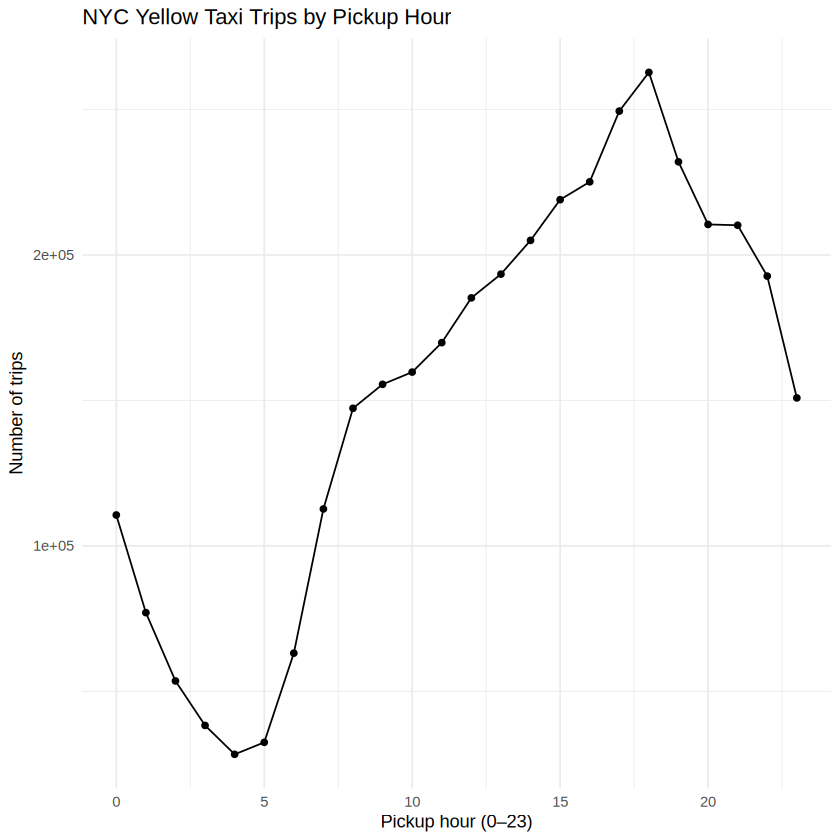

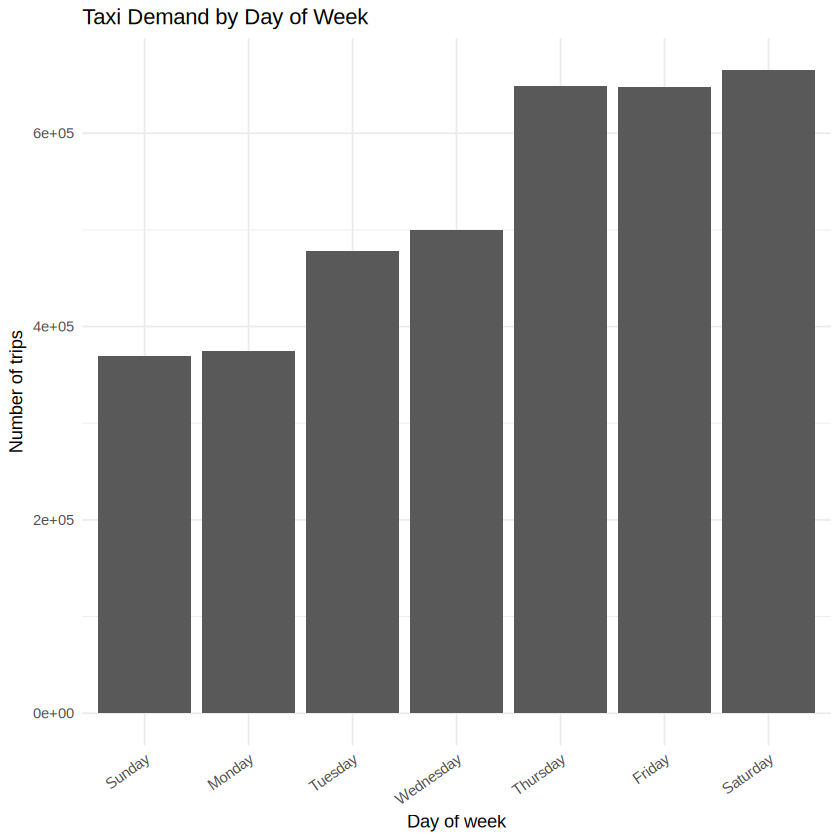

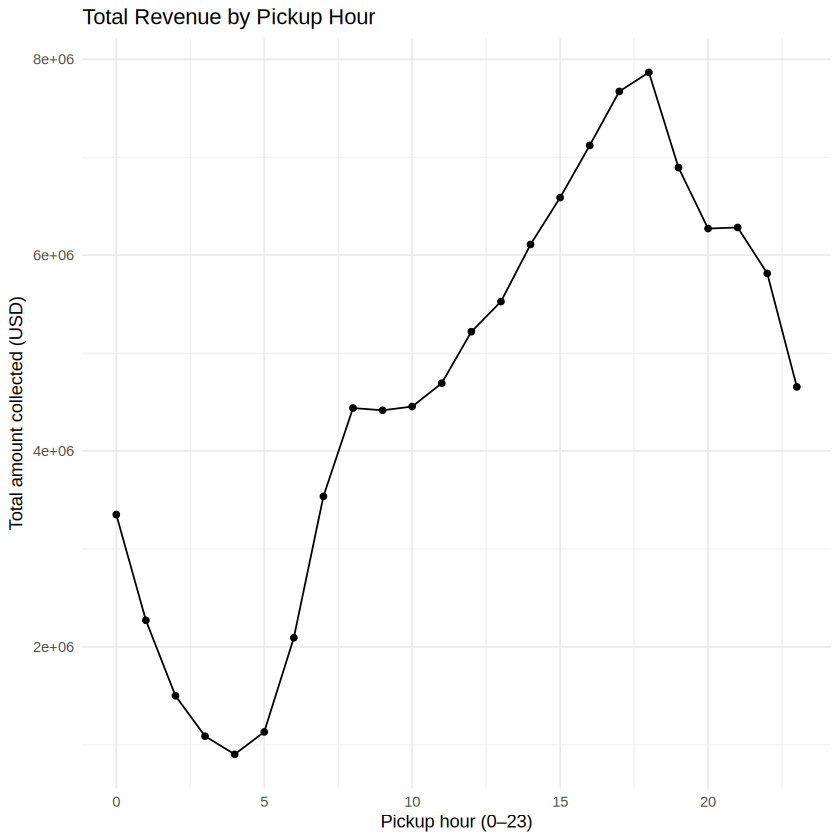

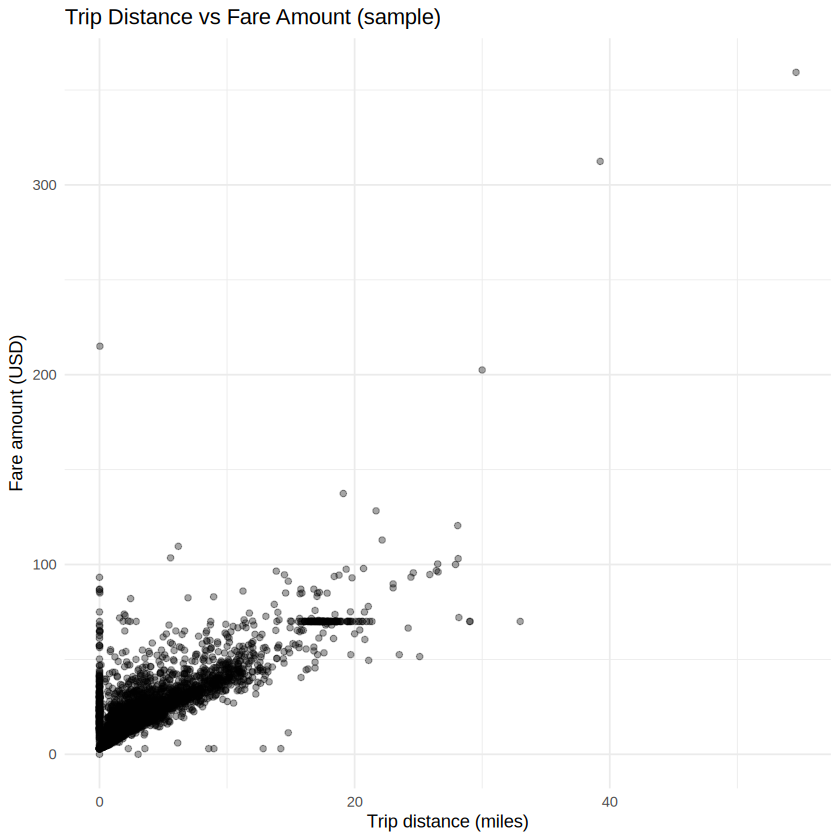

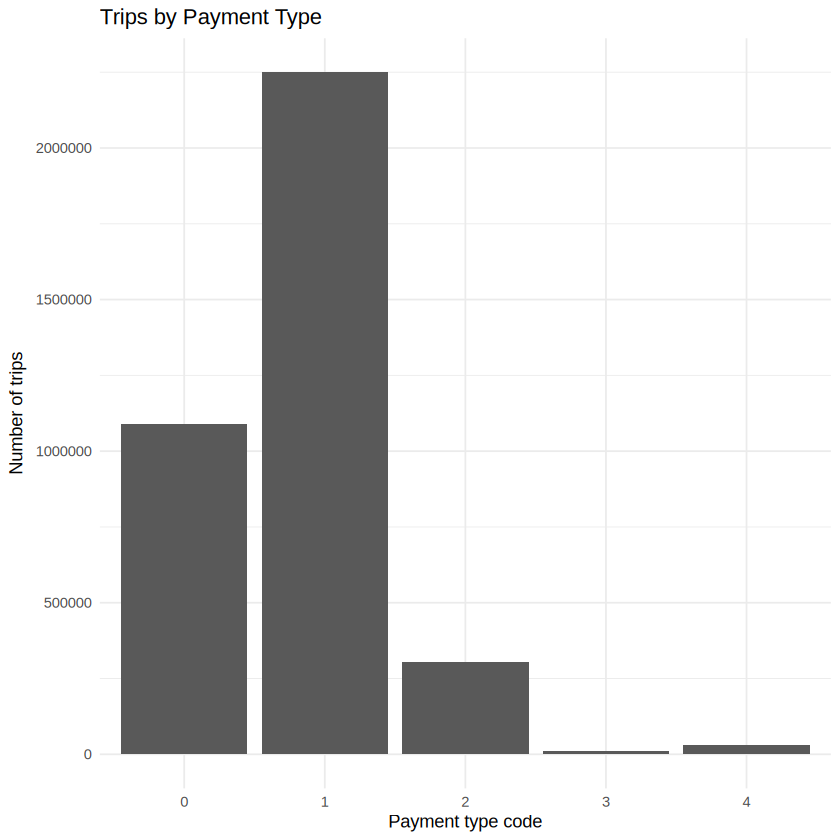

In [37]:
p1 <- ggplot(trips_by_hour, aes(x = pickup_hour, y = trip_count)) +
  geom_line() + geom_point() +
  labs(title = "NYC Yellow Taxi Trips by Pickup Hour",
       x = "Pickup hour (0–23)", y = "Number of trips") +
  theme_minimal()
print(p1)

p2 <- ggplot(trips_by_weekday, aes(x = pickup_weekday, y = trip_count)) +
  geom_col() +
  labs(title = "Taxi Demand by Day of Week",
       x = "Day of week", y = "Number of trips") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 35, hjust = 1))
print(p2)

p3 <- ggplot(fare_revenue_by_hour, aes(x = pickup_hour, y = total_revenue)) +
  geom_line() + geom_point() +
  labs(title = "Total Revenue by Pickup Hour",
       x = "Pickup hour (0–23)", y = "Total amount collected (USD)") +
  theme_minimal()
print(p3)

plot_n <- min(5000L, nrow(trips))
plot_sample <- trips[sample.int(nrow(trips), plot_n)]
p4 <- ggplot(plot_sample, aes(x = .data[[distance_col]], y = .data[[fare_col]])) +
  geom_point(alpha = 0.35) +
  labs(title = "Trip Distance vs Fare Amount (sample)",
       x = "Trip distance (miles)", y = "Fare amount (USD)") +
  theme_minimal()
print(p4)

if (exists("payment_summary")) {
  p5 <- ggplot(payment_summary, aes(x = factor(payment_type), y = trip_count)) +
    geom_col() +
    labs(title = "Trips by Payment Type",
         x = "Payment type code", y = "Number of trips") +
    theme_minimal()
  print(p5)
}

In [39]:
# Create route frequency and revenue summaries

route_counts <- trips[
  ,
  .(trip_count = .N),
  by = .(
    pickup_borough,
    pickup_zone,
    dropoff_borough,
    dropoff_zone
  )
]

setorder(route_counts, -trip_count)

route_revenue <- trips[
  ,
  .(
    total_revenue = sum(get(total_col), na.rm = TRUE),
    trip_count = .N
  ),
  by = .(
    pickup_borough,
    pickup_zone,
    dropoff_borough,
    dropoff_zone
  )
]

setorder(route_revenue, -total_revenue)

# Display top 10 routes
cat("Top 10 most frequent routes:\n")
print(head(route_counts, 10))

cat("Top 10 highest-revenue routes:\n")
print(head(route_revenue, 10))

Top 10 most frequent routes:
    pickup_borough           pickup_zone dropoff_borough          dropoff_zone
            <char>                <char>          <char>                <char>
 1:      Manhattan Upper East Side South       Manhattan Upper East Side North
 2:      Manhattan Upper East Side North       Manhattan Upper East Side South
 3:      Manhattan Upper East Side North       Manhattan Upper East Side North
 4:      Manhattan Upper East Side South       Manhattan Upper East Side South
 5:      Manhattan        Midtown Center       Manhattan Upper East Side South
 6:      Manhattan Upper East Side South       Manhattan        Midtown Center
 7:      Manhattan   Lincoln Square East       Manhattan Upper West Side South
 8:      Manhattan Upper West Side South       Manhattan Upper West Side North
 9:      Manhattan Upper West Side South       Manhattan   Lincoln Square East
10:      Manhattan       Lenox Hill West       Manhattan Upper East Side North
    trip_count
        

## 12. Export summary tables

In [40]:
data.table::fwrite(trips_by_hour, "/content/trips_by_hour.csv")
data.table::fwrite(trips_by_weekday, "/content/trips_by_weekday.csv")
data.table::fwrite(fare_revenue_by_hour, "/content/fare_revenue_by_hour.csv")
data.table::fwrite(route_counts[1:min(20, .N)], "/content/top_routes_by_frequency.csv")
data.table::fwrite(route_revenue[1:min(20, .N)], "/content/top_routes_by_revenue.csv")
cat("Summary CSV files saved under /content/. Download them using the Colab Files panel.\n")

Summary CSV files saved under /content/. Download them using the Colab Files panel.


## 13. Observations, critical analysis, and conclusion

After running the notebook, write conclusions based on the results displayed above:

1. Identify the busiest pickup hour and weekday.
2. Report the most frequent and highest-revenue routes.
3. Describe the relationship between trip distance and fare.
4. Identify the most common payment type, if available.
5. Compare measured execution times for vectorized, functional, and `data.table` approaches.
6. Compare sequential and parallel timings; report the measured speedup.
7. Discuss execution time, memory utilization, readability, and scalability.
8. Recommend an approach based on your actual experimental results.